Finished epoch 1 for lambda = 0.001
Finished epoch 2 for lambda = 0.001
Finished epoch 3 for lambda = 0.001
Lambda: 0.001 | Accuracy: 39.02% | Sparsity: 0.02%
Finished epoch 1 for lambda = 0.01
Finished epoch 2 for lambda = 0.01
Finished epoch 3 for lambda = 0.01
Lambda: 0.01 | Accuracy: 38.20% | Sparsity: 0.01%
Finished epoch 1 for lambda = 0.1
Finished epoch 2 for lambda = 0.1
Finished epoch 3 for lambda = 0.1
Lambda: 0.1 | Accuracy: 37.73% | Sparsity: 0.01%


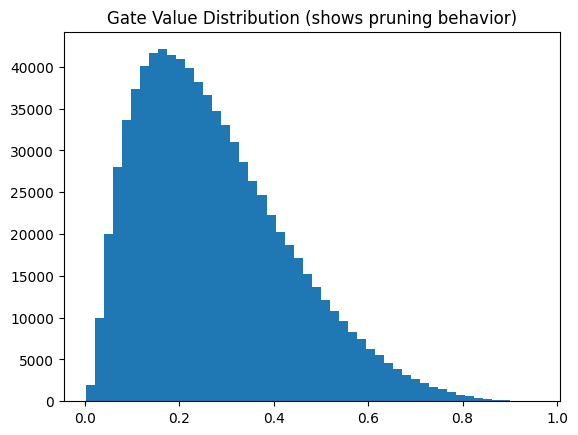


FINAL RESULTS:
(0.001, 39.02, 0.016453783151326052)
(0.01, 38.2, 0.01267550702028081)
(0.1, 37.73, 0.01279738689547582)


In [3]:

!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DATASET (CIFAR-10)
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)


testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)


trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


# CUSTOM PRUNABLE LAYER
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Standard weights and bias
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Personal touch: renamed gate_scores → gate_params
        # These parameters decide which weights remain active
        self.gate_params = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Convert gate_params into values between 0 and 1
        gates = torch.sigmoid(self.gate_params)

        # Element-wise multiplication → pruning happens here
        pruned_weights = self.weight * gates

        return F.linear(x, pruned_weights, self.bias)

# MODEL
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


# SPARSITY LOSS (L1 on gates)
def sparsity_loss(model):
    loss = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_params)
            loss += gates.sum()
    return loss


# TEST ACCURACY
def test_accuracy(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in testloader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    return 100 * correct / total


# SPARSITY %
def calculate_sparsity(model):
    total = 0
    zero = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_params)
            total += gates.numel()
            zero += (gates < 1e-2).sum().item()
    return 100 * zero / total


# TRAIN FUNCTION
def train_model(lambda_val):
    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(3):  # kept small due to time constraints
        model.train()
        for data, target in trainloader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            output = model(data)

            # Classification loss
            loss = criterion(output, target)

            # Sparsity loss (encourages pruning)
            s_loss = sparsity_loss(model)

            # Total loss
            total_loss = loss + lambda_val * s_loss

            total_loss.backward()
            optimizer.step()

        print(f"Finished epoch {epoch+1} for lambda = {lambda_val}")

    acc = test_accuracy(model)
    sparsity = calculate_sparsity(model)

    return model, acc, sparsity


# RUN EXPERIMENTS
lambdas = [0.001, 0.01, 0.1]
results = []

for lam in lambdas:
    model, acc, sparsity = train_model(lam)
    results.append((lam, acc, sparsity))
    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")


# PLOT GATE DISTRIBUTION
all_gates = []

for m in model.modules():
    if isinstance(m, PrunableLinear):
        gates = torch.sigmoid(m.gate_params).detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution (shows pruning behavior)")
plt.show()

print("\nFINAL RESULTS:")
for r in results:
    print(r)